<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ%20Uzmanl%C4%B1%C4%9F%C4%B1-5B2C1E?style=for-the-badge&logo=python&logoColor=white" alt="ECS VB&YZ 90"/>

# Hafta 12: Ek: Cnn Hurma Siniflandirma

**YAPAY ZEKA MÜHENDİSLİĞİ** · Modül 12 · 6 Saat

---

<a href="https://colab.research.google.com/github/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta12/ek_cnn_hurma_siniflandirma.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab'da Aç"/></a>&nbsp;
<a href="https://github.com/DrMuratAltun/VB-YZ-90/blob/main/notebooks/hafta12/ek_cnn_hurma_siniflandirma.ipynb"><img src="https://img.shields.io/badge/GitHub'da%20A%C3%A7-181717?style=flat&logo=github&logoColor=white" alt="GitHub'da Aç"/></a>

</div>

# Proje Hakkında
Hurma görüntülerinden hurma türlerini sınıflandıran uygulama.

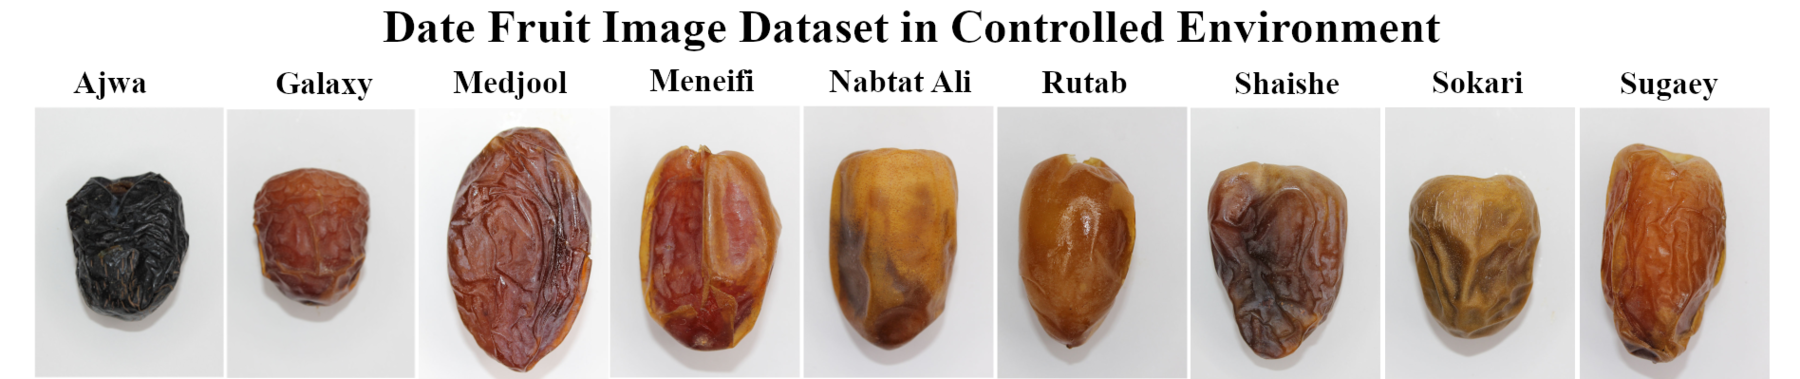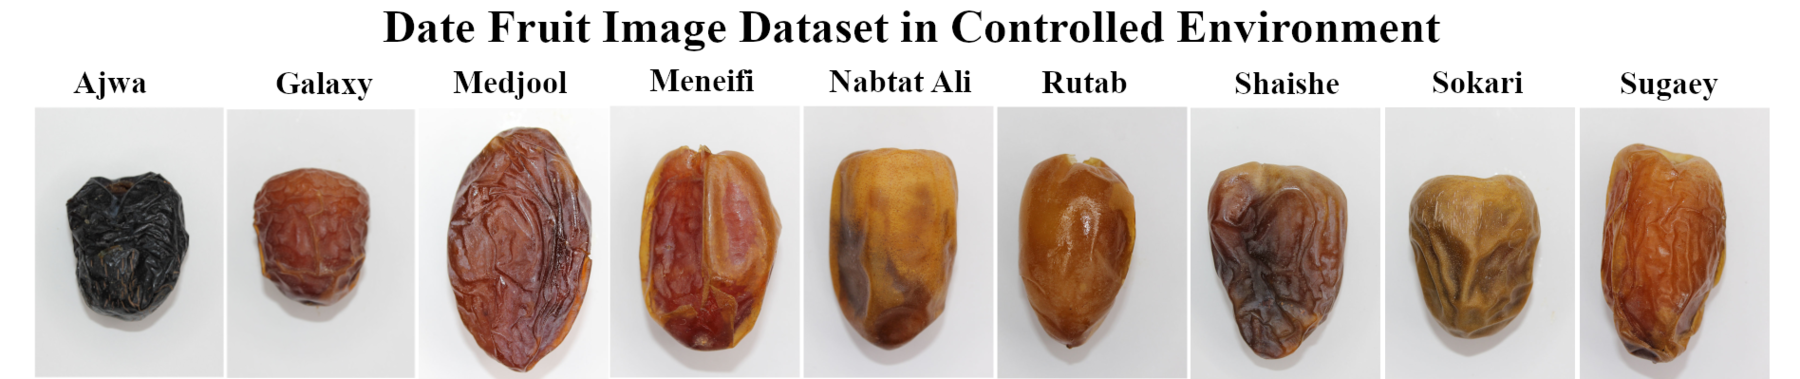

# Kütüphanelerin Yüklenmesi

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `matplotlib` | Görselleştirme |
| `numpy` | Sayısal hesaplamalar |
| `os` | Dosya işlemleri |
| `pandas` | Veri analizi |
| `pathlib` | Yardımcı kütüphane |
| `tensorflow` | Derin öğrenme |
| `warnings` | Uyarı yönetimi |


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print("tf versiyon:", tf.__version__)
import warnings
warnings.filterwarnings('ignore')

2024-05-07 04:04:32.612945: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-07 04:04:32.613109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-07 04:04:32.782995: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tf versiyon: 2.15.0


# Veri Yükleme

### Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu

In [2]:
#Dosya yolu ve etiketlerden dataframe oluşturma fonksiyonu
def create_dataset(folders,path):
    data = {'imgpath': [], 'labels': []}
    for folder in folders:
        folderpath = os.path.join(path, folder)
        files = os.listdir(folderpath)
        
        for file in files:
            filepath = os.path.join(folderpath, file)
            data['imgpath'].append(filepath)
            data['labels'].append(folder)

    dataset = pd.DataFrame(data)
    return dataset

In [3]:
ls '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'

 Ajwa/     Medjool/  'Nabtat Ali'/   Shaishe/   Sugaey/
 Galaxy/   Meneifi/   Rutab/         Sokari/


### Veri seti yolu ve klasör adları ile data frame oluştur

In [4]:
# Veri seti yolu ve klasör adları ile data frame oluştur
path1 = '/kaggle/input/date-fruit-image-dataset-in-controlled-environment'
folders1 = ['Ajwa','Medjool', 'Nabtat Ali',   'Shaishe',   
            'Sugaey','Galaxy', 'Meneifi','Rutab','Sokari'] 
df=create_dataset(folders1,path1)
df.head()

,imgpath,labels
0,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
1,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
2,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
3,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa
4,/kaggle/input/date-fruit-image-dataset-in-cont...,Ajwa


### Veri seti bilgileri

In [5]:
# Veri seti bilgileri
print('-- Veri seti bilgileri --\n')
print(f'Görsel Sayısı: {df.shape[0]}\n')
print(f'Etiket sayısı: {len(df.labels.unique())}\n')
print(f'Etiketler {df.labels.unique()}')

-- Veri seti bilgileri --

Görsel Sayısı: 1658

Etiket sayısı: 9

Etiketler ['Ajwa' 'Medjool' 'Nabtat Ali' 'Shaishe' 'Sugaey' 'Galaxy' 'Meneifi'
 'Rutab' 'Sokari']


### Görselleştirme

Veriyi grafik ile inceliyoruz.

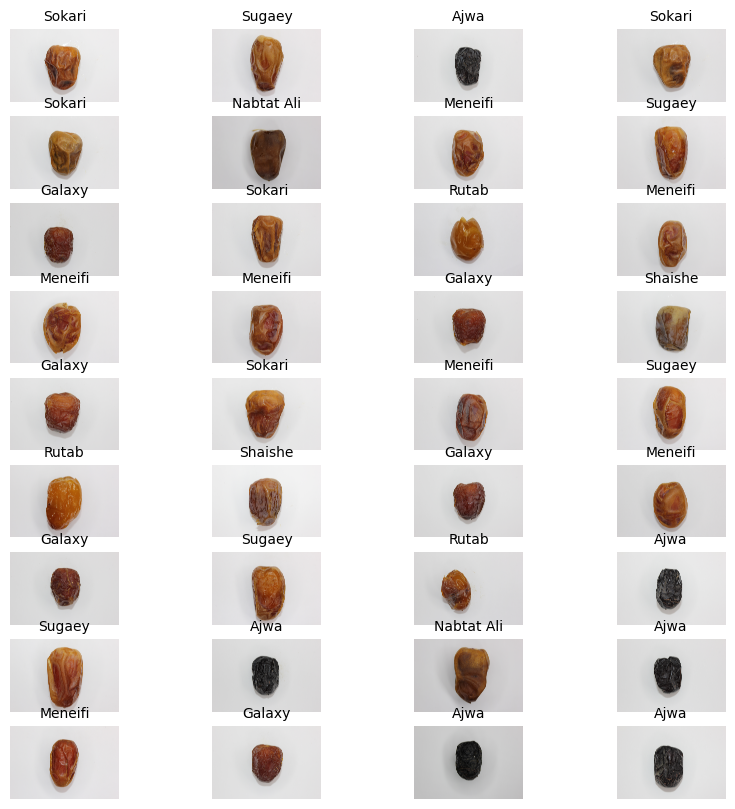

In [6]:
# Veri Görselleştirme
import random
import matplotlib.gridspec as gridspec
from PIL import Image
rows = 9
cols = 4

selected_indices = random.sample(range(len(df)), rows * cols)

fig, axes = plt.subplots(rows, cols, figsize = (10, 10))
gs = gridspec.GridSpec(rows, cols, wspace = 0.0, hspace = 0.0)

for i, idx in enumerate(selected_indices):
    row = i // cols
    col = i % cols
    img_path = df['imgpath'].iloc[idx]
    label = df['labels'].iloc[idx]
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    axes[row, col].set_title(label, fontsize = 10)

plt.show()

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

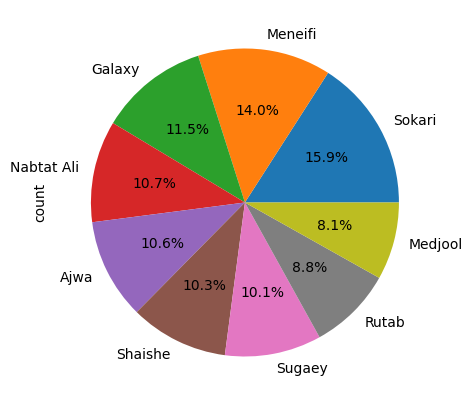

In [7]:
# pie plot label distribution
df.labels.value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(5,5));

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `sklearn` | Makine öğrenmesi |


In [9]:
from sklearn.model_selection import train_test_split

# Veri setini etiketlere göre bölme
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['labels'])
test_df, val_df = train_test_split(test_df, test_size=0.5, random_state=42, stratify=test_df['labels'])

train_df.shape, val_df.shape, test_df.shape

((1326, 2), (166, 2), (166, 2))

### Veri Gruplama ve Analiz

Verileri kategorilere göre gruplayıp analiz ediyoruz.

In [10]:
train_df.labels.value_counts(normalize=True)

labels
Sokari        0.159125
Meneifi       0.139517
Galaxy        0.114630
Nabtat Ali    0.107089
Ajwa          0.105581
Shaishe       0.103318
Sugaey        0.101056
Rutab         0.088235
Medjool       0.081448
Name: proportion, dtype: float64

### Veri artırmalı versiyon

In [12]:
# Veri artırmalı versiyon
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
seed = 42
batch_size = 64
img_size = (224, 224)

# Veri artırma için ImageDataGenerator oluşturma
train_generator = ImageDataGenerator(
    rescale=1./255,rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,
    shear_range=0.2,zoom_range=0.2,horizontal_flip=True,fill_mode='nearest'
)

val_generator = ImageDataGenerator(rescale=1./255)
test_generator = ImageDataGenerator(rescale=1./255)

# Train veri akışını oluşturma
train_data = train_generator.flow_from_dataframe(
    train_df,x_col='imgpath',y_col='labels',color_mode='rgb',class_mode='categorical',
    batch_size=batch_size,target_size=img_size,shuffle=True,seed=seed
)

# Validation ve test veri akışlarını oluşturma
val_data = val_generator.flow_from_dataframe(
    val_df,x_col='imgpath',y_col='labels',color_mode='rgb',class_mode='categorical',
    batch_size=batch_size,target_size=img_size,shuffle=False
)

test_data = test_generator.flow_from_dataframe(
    test_df, x_col='imgpath',y_col='labels',color_mode='rgb',class_mode='categorical',
    batch_size=batch_size,target_size=img_size,shuffle=False
)

Found 1326 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.


In [12]:
%%time
#V1
# görsel ön işleme ve generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
seed = 42 #random state=42
batch_size = 64
img_size = (224, 224)

generator = ImageDataGenerator(rescale = 1./255)

train_data = generator.flow_from_dataframe(train_df, x_col = 'imgpath', y_col = 'labels', 
                                           color_mode = 'rgb', class_mode = 'categorical', 
                                           batch_size = batch_size, target_size = img_size, 
                                           shuffle = True, seed = seed)

val_data = generator.flow_from_dataframe(val_df, x_col = 'imgpath', y_col = 'labels', 
                                         color_mode = 'rgb', class_mode = 'categorical', 
                                         batch_size = batch_size, target_size = img_size, 
                                         shuffle = False)

test_data = generator.flow_from_dataframe(test_df, x_col = 'imgpath', y_col = 'labels', 
                                          color_mode = 'rgb', class_mode = 'categorical', 
                                          batch_size = batch_size, target_size = img_size, 
                                          shuffle = False)

Found 1326 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.
Found 166 validated image filenames belonging to 9 classes.
CPU times: user 80.2 ms, sys: 69.3 ms, total: 149 ms
Wall time: 1.85 s


# Model Oluşturma

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `tensorflow` | Derin öğrenme |


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.losses import CategoricalCrossentropy

model = Sequential()
model.add(Input(shape=(224, 224, 3)))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(9, activation='softmax'))  # 9 kategori

# Modelin derlenmesi
model.compile(optimizer='adam', loss=CategoricalCrossentropy(), metrics=['accuracy'])#kategorik etiketler varsa loss = 'CategoricalCrossentropy()'

# Model Yapısı

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,108,297 (19.49 MB)

 Trainable params: 5,108,297 (19.49 MB)

 Non-trainable params: 0 (0.00 B)

# Model Eğitme

In [15]:
%%time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# En düşük loss değerinde eğitimin durmasını sağla
model_es = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 2, restore_best_weights = True)
model_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 1, mode = 'min')

history = model.fit(train_data, validation_data = val_data, 
                    epochs = 20, callbacks = [model_es, model_rlr])

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 227s 8s/step - accuracy: 0.1595 - loss: 2.2713 - val_accuracy: 0.2711 - val_loss: 1.8312 - learning_rate: 0.0010
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 207s 8s/step - accuracy: 0.3636 - loss: 1.6486 - val_accuracy: 0.6747 - val_loss: 1.0245 - learning_rate: 0.0010
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 196s 7s/step - accuracy: 0.6626 - loss: 0.9476 - val_accuracy: 0.7108 - val_loss: 0.8832 - learning_rate: 0.0010
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 188s 7s/step - accuracy: 0.7252 - loss: 0.7926 - val_accuracy: 0.8072 - val_loss: 0.5848 - learning_rate: 0.0010
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 209s 8s/step - accuracy: 0.7759 - loss: 0.6440 - val_accuracy: 0.7349 - val_loss: 0.7850 - learning_rate: 0.0010
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 218s 8s/step - accuracy: 0.8272 - loss: 0.5652 - val_accuracy: 0.8554 - val_loss: 0.4426 - learning_rate: 2.0000e-04
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 192s 7s/step - accuracy: 0.8552 - loss: 0.4090 - val

# Modeli Değerlendir

In [16]:
test_results = model.evaluate(test_data, verbose = 0)

print(f'Test Loss: {test_results[0]:.5f}')
print(f'Test Accuracy: {(test_results[1] * 100):.2f}%')

Test Loss: 0.29956
Test Accuracy: 90.96%


### Modeli kaydet

In [17]:
#Modeli kaydet
model.save('/kaggle/working/date_fruit_class_cnn.h5')

# Transfer Learning

### Kütüphaneleri Yükle

In [26]:
# Kütüphaneleri Yükle

### Kütüphanelerin Yüklenmesi

| Kütüphane | Amacı |
|-----------|-------|
| `tensorflow` | Derin öğrenme |


In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.losses import CategoricalCrossentropy

### Sinir Ağı Modeli

Derin öğrenme modeli oluşturup eğitiyoruz.

In [52]:
# Vgg16 ile model oluşturma
img_width, img_height = 224, 224
base_model = VGG16(weights='imagenet', input_shape=(img_width, img_height, 3), include_top=False)

model = Sequential()
model.add(base_model)

for layer in base_model.layers:
    layer.trainable = False

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(9, activation='softmax'))

model.compile(optimizer=Adam(), loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [53]:
%%time
# Transfer Learning Modeli Eğitme
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# En düşük loss değerinde eğitimin durmasını sağla
model_es = EarlyStopping(monitor = 'val_loss', mode = 'min', patience = 2, restore_best_weights = True)
model_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 1, mode = 'min')

history = model.fit(train_data, validation_data = val_data, 
                    epochs = 20, callbacks = [model_es, model_rlr])

ValueError: Unrecognized data type: x=<keras.src.legacy.preprocessing.image.ImageDataGenerator object at 0x7cc7dc7bf9d0> (of type <class 'keras.src.legacy.preprocessing.image.ImageDataGenerator'>)

# Değerlendirme

In [ ]:
test_results = model.evaluate(test_data, verbose = 0)

print(f'Test Loss: {test_results[0]:.5f}')
print(f'Test Accuracy: {(test_results[1] * 100):.2f}%')

# Modeli Kaydet

In [ ]:
model.save('/kaggle/working/date_fruit_vgg_class_cnn.h5')

---

<div align="center">

<img src="https://img.shields.io/badge/ECS-Veri%20Bilimi%20%26%20YZ-5B2C1E?style=flat-square&logo=python&logoColor=white" alt="ECS"/>

**Dr. Murat Altun** · Veri Bilimi ve Yapay Zeka Eğitmeni

<a href="https://yapayzekaokulum.com">Yapay Zeka Okulum</a> ·
<a href="https://gencyz.com">GençYZ</a> ·
<a href="https://yz-araclari.com">YZ Araçları</a> ·
<a href="https://scholargent.com">ScholarAI</a> ·
<a href="https://drmurataltun.github.io">Kişisel Site</a>

<a href="https://drmurataltun.github.io/VB-YZ-90/">drmurataltun.github.io/VB-YZ-90</a>

---

*Bu materyal ECS Veri Bilimi ve Yapay Zeka Uzmanlığı Programı için hazırlanmıştır.*

© 2026 Dr. Murat Altun. Tüm hakları saklıdır.

</div>